## Import Libraries

In [1]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os, json, imageio, base64
from scipy.spatial.transform import Rotation
from IPython.display import display, HTML
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
from shared_tracker import RunLogger
from helper import plot_loss_reward, record_all_seeds_2D, plot_episode_traces
# Change this to your own path if needed.
XML_PATH     = "segway_2.xml"

SAVE_DIR     = "SavedSeeds"

TRAIN_SEEDS  = [42]
VERIFY_SEEDS = [788, 999, 555, 321, 444]
os.makedirs(SAVE_DIR, exist_ok=True)

## Segway starts from the ground

In [2]:
def get_ground_contact_z(xml_path, tilt=0.0):
    """
    Find the correct z so the segway sits ON the ground
    at the given tilt — not floating, not underground.
    """
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)

    # set tilt at high z, drop freely with no control
    mujoco.mj_resetData(model, data)
    rot  = Rotation.from_euler('y', tilt)
    quat = rot.as_quat()
    data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]
    data.qpos[2]   = 2.0   # start well above ground
    data.qvel[:]   = 0.0
    mujoco.mj_forward(model, data)

    # drop until it settles — no control, gravity only
    for _ in range(2000):
        data.ctrl[:] = 0.0
        mujoco.mj_step(model, data)
        # settled when vertical velocity near zero and low height
        if abs(data.qvel[2]) < 0.001 and data.qpos[2] < 0.5:
            break

    return data.qpos[2]


# find ground z for different tilts
print("Ground contact heights:")
for tilt in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    z = get_ground_contact_z(XML_PATH, tilt)
    print(f"  tilt={tilt:.1f} rad "
          f"({np.degrees(tilt):.1f}°) → z={z:.4f}")
    
    
# run once at startup — build lookup table
print("Building ground contact lookup table...")
GROUND_Z_TABLE = {}
for tilt in np.arange(0.0, 1.1, 0.05):
    GROUND_Z_TABLE[round(tilt, 2)] = \
        get_ground_contact_z(XML_PATH, tilt)
    GROUND_Z_TABLE[round(-tilt, 2)] = \
        GROUND_Z_TABLE[round(tilt, 2)]  # symmetric
print("Done.")
print(GROUND_Z_TABLE)


def get_z_for_tilt(tilt):
    """Look up nearest precomputed z for given tilt."""
    key = round(round(abs(tilt) / 0.05) * 0.05, 2)
    key = min(key, 1.0)
    return GROUND_Z_TABLE.get(key, GROUND_Z_TABLE[0.0])


model    = mujoco.MjModel.from_xml_path(XML_PATH)

# Joint lookup (do once)
rw_joint_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "joint_reaction_wheel")
rw_qvel_addr = model.jnt_dofadr[rw_joint_id]
print(f"RW joint id={rw_joint_id}, qvel addr={rw_qvel_addr}")

Ground contact heights:
  tilt=0.0 rad (0.0°) → z=0.0730
  tilt=0.1 rad (5.7°) → z=0.0740
  tilt=0.2 rad (11.5°) → z=0.0740
  tilt=0.3 rad (17.2°) → z=0.0740
  tilt=0.4 rad (22.9°) → z=0.0740
  tilt=0.5 rad (28.6°) → z=0.0740
Building ground contact lookup table...
Done.
{np.float64(0.0): np.float64(0.07301796866829649), np.float64(0.05): np.float64(0.07398984116042481), np.float64(-0.05): np.float64(0.07398984116042481), np.float64(0.1): np.float64(0.07398862916249783), np.float64(-0.1): np.float64(0.07398862916249783), np.float64(0.15): np.float64(0.07398702063271577), np.float64(-0.15): np.float64(0.07398702063271577), np.float64(0.2): np.float64(0.07398811880174053), np.float64(-0.2): np.float64(0.07398811880174053), np.float64(0.25): np.float64(0.07398838358012261), np.float64(-0.25): np.float64(0.07398838358012261), np.float64(0.3): np.float64(0.07398765299807862), np.float64(-0.3): np.float64(0.07398765299807862), np.float64(0.35): np.float64(0.07398694924527938), np.float64(-0.

## Other functions

In [3]:
def get_obs(data):
    quat  = data.qpos[3:7]
    rot   = Rotation.from_quat(
        [quat[1], quat[2], quat[3], quat[0]])
    theta = rot.as_euler('xyz')[1]
    psi = rot.as_euler('xyz')[2]
    rw_w = data.qvel[7] # reaction wheel sped in rad/s
    # [x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot]
    return np.array([data.qpos[0], data.qvel[0], data.qpos[1], data.qvel[1],
                     theta, data.qvel[4], psi, data.qvel[5], rw_w],
                    dtype=np.float32)


def normalize_obs(obs):
    x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs
    return np.array([
        np.clip(x         / 2.4,  -1, 1),
        np.clip(x_dot     / 5.0,  -1, 1),
        np.clip(y         / 2.4,  -1, 1),
        np.clip(y_dot     / 5.0,  -1, 1),
        np.clip(theta     / 1.57, -1, 1),
        np.clip(theta_dot / 5.0,  -1, 1),
        np.clip(psi       / 1.57, -1, 1),
        np.clip(psi_dot   / 5.0,  -1, 1),
        np.clip(rw_w      / 100.0, -1, 1)
    ], dtype=np.float32)

def make_inp(obs, x_goal, y_goal):
    dx = x_goal - obs[0];  dy = y_goal - obs[2]
    dist      = np.sqrt(dx**2 + dy**2)
    dist_norm = float(np.clip(dist / 5., -1, 1))
    desired_heading    = np.arctan2(dy, dx)
    heading_error      = np.arctan2(np.sin(desired_heading - obs[6]),
                                    np.cos(desired_heading - obs[6]))
    heading_error_norm = float(np.clip(heading_error / np.pi, -1, 1))
    # obs[8] is rw_rpm_norm (9th element of the new obs)
    return np.array([*normalize_obs(obs), dist_norm, heading_error_norm],
                    dtype=np.float32)   # normalize_obs(obs) should now return 9 elements

## PPO and reward function

In [4]:
class NavPPO(nn.Module):
    def __init__(self, torque_max=5.0):
        super().__init__()
        self.torque_max = torque_max
        # Input: 9D obs + dist + heading error = 11        
        # ── Shared trunk ──────────────────────────────────────────
        self.net = nn.Sequential(
        nn.Linear(11, 512), nn.Tanh(),
        nn.Linear(512, 512), nn.Tanh(),
        nn.Linear(512, 256), nn.Tanh(),
        nn.Linear(256, 128), nn.Tanh(),
        )
         # ── Actor head (was: single Linear) ──────────────────────────────────
        self.actor_head = nn.Sequential(
        nn.Linear(128, 128), nn.Tanh(),
        nn.Linear(128, 64),  nn.Tanh(),
        nn.Linear(64,  2),               # [w_torque, r_torque]
        )

        self.actor_log_std = nn.Parameter(
            torch.tensor([-0.5, -0.5]))   # std≈0.6
        # ── Critic head (was: single Linear) ─────────────────────────────────
        self.critic_head = nn.Sequential(
        nn.Linear(128, 128), nn.Tanh(),
        nn.Linear(128, 64),  nn.Tanh(),
        nn.Linear(64,  1),               # scalar V(s)
        )

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)
            # Target just the final output layer of each head for small-init treatment
        nn.init.orthogonal_(self.actor_head[-1].weight, 0.01)  # small init keeps early actions near-zero
        nn.init.orthogonal_(self.critic_head[-1].weight, 1.0)  # critic output uses standard scale

    def forward(self, x):
        s = self.net(x)
        return self.actor_head(s), self.critic_head(s)

    def get_action(self, obs, goal_x, goal_y,
                deterministic=False):

        inp = make_inp(obs, goal_x, goal_y)
        t         = torch.FloatTensor(inp)
        mean, val = self(t)
        std       = self.actor_log_std.exp().clamp(0.1, 2.0)
        dist      = torch.distributions.Normal(mean, std)
        raw       = mean if deterministic else dist.rsample()
        logp      = dist.log_prob(raw).sum(-1)
        torques    = torch.tanh(raw) * self.torque_max
        # torque[0] is wheel torque, torque[1] is reaction wheel torque
        return torques[0].item(), torques[1].item(), logp, val

def nav_reward(obs, prev_pos, goal_x, goal_y, at_goal, done, step):
    x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs

    
    if done:
        early_penalty = max(0, (3000 - step) / 3000) * 10.0
        return -30.0 - early_penalty
    if at_goal: return 100.0

    # Current distance to goal
    curr_dist = np.sqrt((x - goal_x)**2 + (y - goal_y)**2)
    # Previous distance to goal
    prev_dist = np.sqrt((prev_pos[0] - goal_x)**2 + (prev_pos[1] - goal_y)**2)

    # progress moving closer to goal
    r = (prev_dist - curr_dist) * 20.0

    # continuous pull — penalise being far from goal
    r -= curr_dist * 0.1
    
    r += 0.03  # ~+60 over a 3000-step episode for staying up

    desired_heading = np.arctan2(goal_y - y, goal_x - x)
    heading_error   = np.arctan2(np.sin(desired_heading - psi),
                                  np.cos(desired_heading - psi))
    r += (1.0 - abs(heading_error) / np.pi) * 0.05

    #small penalty for reaction wheel above n rev/s
    n = 30
    r -= max(0, abs(rw_w) - 6.28*n) * 0.01 
    # stability
    if abs(theta) > 0.20:
        r -= (abs(theta) - 0.2) * 5.0

    return float(r)

## Train PPO (Single)

In [5]:
# ==========================================================================
# PPO  —  instrumented train_nav.
# Replace your existing PPO train_nav with this. Changes marked  # <-- NEW
# Same step budget and same RunLogger call as SAC, so logs are comparable.
# Everything else is your original PPO logic, untouched.
# ==========================================================================
def train_nav(x_start=0.0, x_goal=2.0, y_start=0.0, y_goal=2.0,
              seed=42, tag="nav_v4",
              max_steps=600_000):              # <-- NEW: step budget (was max_episodes)
    torch.manual_seed(seed); np.random.seed(seed)

    net       = NavPPO(torque_max=5.0)
    optimizer = optim.Adam(net.parameters(), lr=3e-3, eps=1e-5)
    #Hyperparameters:
    # STEPS: how many steps of interaction (rollout) before each update
    # EPOCHS: how many passes of PPO update to make per rollout
    # CLIP: PPO clipping parameter — how far new policy can deviate from old one

    STEPS, EPOCHS, CLIP   = 2048, 10, 0.2
    GAMMA, LAM, MB        = 0.99, 0.95, 256
    ENT_START, ENT_END    = 0.01, 0.002
    ENT_DECAY             = 3000
    MAX_EP_STEPS          = 3000
    #max possible sim time based on step limit and timestep size = 3000 steps * 0.002s/step
    rewards=[]; losses=[]; best_avg=-9999; best_weights=None

    def gae(rews, vals, dones, nv):
        adv,g=[],0
        for r,v,d in zip(reversed(rews),reversed(vals),reversed(dones)):
            delta=r+GAMMA*nv*(1-d)-v; g=delta+GAMMA*LAM*(1-d)*g
            adv.insert(0,g); nv=v
        return adv

    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)

    def reset_env():
        mujoco.mj_resetData(model,data)
        data.qpos[0]=x_start; data.qpos[1]=y_start
        data.qpos[2]=get_z_for_tilt(0.0); data.qpos[3:7]=[1,0,0,0]
        data.qvel[:]=0.0; data.qvel[4]=np.random.uniform(-0.01,0.01)
        mujoco.mj_forward(model,data); return get_obs(data)

    def env_step(wheel_torque, reaction_torque):
        u_wheel=float(np.clip(wheel_torque,-5.,5.)); u_react=float(np.clip(reaction_torque,-5.,5.))
        data.ctrl[0]=-u_wheel; data.ctrl[1]=u_react
        mujoco.mj_step(model,data); obs=get_obs(data); x,x_dot,y,y_dot,theta,theta_dot,psi,psi_dot, rw_w =obs
        dist_to_goal = np.sqrt((x-x_goal)**2 + (y-y_goal)**2)
        done=(abs(x)>2.8 or abs(y)>2.8 or abs(theta)>0.5)
        at_goal=(dist_to_goal<0.15 and abs(theta)<0.25)
        return obs,done,at_goal

    logger = RunLogger("PPO", seed, log_every_steps=2000)   # <-- NEW


    obs=reset_env(); ep_total=0.0; prev_pos=np.array([obs[0], obs[2]])
    ep_count=0; ep_step=0; total_steps=0                   # <-- NEW: total_steps
    ENT=ENT_START


    print(f"\nPPO | A=({x_start},{y_start}) -> B=({x_goal},{y_goal}) | budget={max_steps:,} steps")
    print(f"{'Steps':>9} | {'Ep':>5} | {'Avg100':>8} | {'Rec%':>6} | {'Loss':>8} | {'std':>5}")
    print("-"*62)

    while total_steps < max_steps:                          # <-- NEW: step budget
        #ol: observations, al: actions, rl: rewards, vl: values, ll: logprobs, dl: dones
        ol,al,rl,vl,ll,dl=[],[],[],[],[],[]
        ep_rewards=[]; ep_arrived_flags=[]                  # <-- NEW: track arrivals
######################
        for _ in range(STEPS):
            with torch.no_grad():
                w_torque,r_torque,logp,value = net.get_action(obs,x_goal,y_goal,deterministic=False)
            ep_step+=1; total_steps+=1                            # <-- NEW: track total steps
            obs2,done,at_goal = env_step(w_torque,r_torque)
            r=nav_reward(obs2,prev_pos,x_goal,y_goal,at_goal,done,ep_step)
            ep_total+=r; prev_pos=np.array([obs2[0], obs2[2]])
            dx = x_goal - obs[0]; dy = y_goal - obs[2]
            dist = np.sqrt(dx**2 + dy**2); dist_norm = float(np.clip(dist / 5., -1, 1))
            desired_heading = np.arctan2(dy, dx); heading_error = desired_heading - obs[6]
            heading_error = np.arctan2(np.sin(heading_error), np.cos(heading_error))
            heading_error_norm = float(np.clip(heading_error / np.pi, -1, 1))
            inp=np.array([*normalize_obs(obs), dist_norm, heading_error_norm],dtype=np.float32)
            ol.append(inp); al.append([w_torque, r_torque]); rl.append(r)
            vl.append(value.item())
            ll.append(logp.item())
            dl.append(float(done or at_goal))
            obs=obs2
            timeout=(ep_step>=MAX_EP_STEPS)
            ################## Idk past here man ##########
            if done or at_goal or timeout:
                if timeout and not at_goal: rl[-1]-=5.0
                ep_rewards.append(ep_total)
                ep_arrived_flags.append(at_goal)            # <-- NEW
                ep_total=0.0; ep_step=0; ep_count+=1
                ENT=ENT_START+(ENT_END-ENT_START)*min(1.0,ep_count/ENT_DECAY)
                obs=reset_env(); prev_pos=np.array([obs[0], obs[2]])

        # PPO Update #
        with torch.no_grad():
            dx = x_goal - obs[0]; dy = y_goal - obs[2]
            dist = np.sqrt(dx**2 + dy**2)
            dist_norm = float(np.clip(dist / 5., -1, 1))
            desired_heading = np.arctan2(dy, dx)
            heading_error = desired_heading - obs[6]
            heading_error = np.arctan2(np.sin(heading_error), np.cos(heading_error))
            heading_error_norm = float(np.clip(heading_error / np.pi, -1, 1))
            inp=np.array([*normalize_obs(obs), dist_norm, heading_error_norm],dtype=np.float32)
            _,nv=net(torch.FloatTensor(inp))
        advantages=gae(rl,vl,dl,nv.item())
        returns=[a+v for a,v in zip(advantages,vl)]
        n=len(ol)
        obs_t=torch.FloatTensor(np.array(ol)); act_t=torch.FloatTensor(al)
        ret_t=torch.FloatTensor(returns); adv_t=torch.FloatTensor(advantages)
        logp_t=torch.FloatTensor(ll)
        adv_t=((adv_t-adv_t.mean())/(adv_t.std()+1e-8))
        batch_loss=0.0
        for _ in range(EPOCHS):
            idx=torch.randperm(n)
            for s in range(0,n,MB):
                i=idx[s:s+MB]
                mean,vals=net(obs_t[i])
                std=net.actor_log_std.exp().clamp(0.1,2.0)
                dist=torch.distributions.Normal(mean,std)
                raw=torch.atanh((act_t[i]/net.torque_max).clamp(-0.999,0.999))
                nlp=dist.log_prob(raw).sum(-1); ent=dist.entropy().mean()
                ratio=(nlp-logp_t[i]).exp().clamp(0.,10.)
                s1=ratio*adv_t[i]; s2_=torch.clamp(ratio,1-CLIP,1+CLIP)*adv_t[i]
                loss=(-torch.min(s1,s2_).mean()
                      +0.5*nn.MSELoss()(vals.squeeze(),ret_t[i])-ENT*ent)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(),0.5); optimizer.step()
                with torch.no_grad(): net.actor_log_std.clamp_(-1.5,0.7)
                batch_loss+=loss.item()

        rewards.extend(ep_rewards); losses.append(batch_loss)

        #log each finished episode in this rollout, identical to SAC
        for ret, arr in zip(ep_rewards, ep_arrived_flags):
            avg, rp = logger.episode_end(total_steps, ep_count, ret, arr, batch_loss)

        if ep_rewards:
            #log both stds separately - useful to see if they diverge
            stds = net.actor_log_std.exp().tolist()
            std_w, std_r = stds[0], stds[1]
            icon = "✅" if avg>0 else "🔄" if avg>-20 else "⏳"
            print(f"{total_steps:>9,} | {ep_count:>5} | {avg:>8.2f} | "
                  f"{rp:>5.1f}% | {batch_loss:>8.3f} | "
                  f"{std_w:.3f} | {std_r:.3f} {icon}", flush=True)
            if avg > best_avg:
                best_avg     = avg
                best_weights = {k:v.clone() for k,v in net.state_dict().items()}
                torch.save(net.state_dict(), f"{SAVE_DIR}/nav_{tag}.pth")


    if best_weights: net.load_state_dict(best_weights)
    return net, rewards, losses, logger            # <-- NEW: also return logger

## Training and Verifying PPO with multiple seeds

In [6]:
def train_one_verify_many(algo_label,
                          train_seed   = 42,
                          verify_seeds = (788, 999, 555, 321, 444,
                                          123, 777, 256, 512, 111),
                          x_start=0.0, x_goal=2.0,
                          y_start=0.0, y_goal=2.0,
                          step_budget=500_000):
    verify_seeds = list(verify_seeds)

    # ---- 1. TRAIN on the single train_seed ----
    print(f"\n{'='*60}\n  {algo_label}  TRAIN seed = {train_seed}\n{'='*60}")
    net, rewards, losses, logger = train_nav(
        x_start=x_start, x_goal=x_goal, y_start=y_start, y_goal=y_goal,
        seed=train_seed, tag=f"cmp_seed{train_seed}",
        max_steps=step_budget)

    # ---- 2. eval helper (deterministic) ----
    def eval_policy(net, seed, n=20):
        torch.manual_seed(seed); np.random.seed(seed)
        model=mujoco.MjModel.from_xml_path(XML_PATH); data=mujoco.MjData(model)
        strict=loose=fell=0; max_xs=[]; times=[]
        for _ in range(n):
            mujoco.mj_resetData(model,data)
            data.qpos[0]=x_start
            data.qpos[1]=y_start 
            data.qpos[2]=get_z_for_tilt(0.0)
            data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
            data.qvel[4]=np.random.uniform(-0.02,0.02)
            mujoco.mj_forward(model,data); obs=get_obs(data); mx=0.0; end="timeout"
            # This loop steps the environment forward using the policy's actions, without exploration noise (deterministic=True).
            for step in range(3000):
                with torch.no_grad():
                    w_t, r_t, _,_=net.get_action(obs,x_goal, y_goal, deterministic=True)
                data.ctrl[0]=-float(np.clip(w_t,-5,5))
                data.ctrl[1]=float(np.clip(r_t,-5,5))
                mujoco.mj_step(model,data)
                obs=get_obs(data)

                #x,_,th,_=obs
                x,_,y,_,th,_,_,_,_=obs
                #mx is the max distance from origin during the episode, used to measure how far it strayed
                mx=max(mx,np.sqrt(x**2+y**2))

                # Rewritten for 2D case
                if abs(x)>2.8 or abs(y)>2.8 or abs(th)>0.5: end="fell"; break
                if (abs(x-x_goal)<0.10 or abs(y-y_goal)<0.10) and abs(th)<0.35:
                    end="strict"; times.append(step*model.opt.timestep); break
                elif (abs(x-x_goal)<0.25 or abs(y-y_goal)<0.25) and abs(th)<0.35:
                    end="loose"; times.append(step*model.opt.timestep)
            strict+=end=="strict"; loose+=end=="loose"; fell+=end=="fell"
            max_xs.append(mx)
        return {"strict_pct":strict/n*100,"loose_pct":(strict+loose)/n*100,
                "fell_pct":fell/n*100,"avg_max_x":float(np.mean(max_xs)),
                "avg_time":float(np.mean(times)) if times else 999.0}

    # ---- 3. VERIFY the one policy on every verify seed ----
    print(f"\n  Verifying {algo_label} policy (trained on {train_seed}) "
          f"on {len(verify_seeds)} unseen seeds:")
    print(f"  {'Seed':>6} | {'Strict%':>8} | {'Loose%':>7} | {'Fell%':>6} | {'Time':>6}")
    print("  " + "-"*48)
    per_seed={}
    for vs in verify_seeds:
        r=eval_policy(net, vs); per_seed[vs]=r
        icon="✅" if r["strict_pct"]>=80 else "🔄" if r["strict_pct"]>=50 else "❌"
        print(f"  {vs:>6} | {r['strict_pct']:>7.0f}% | {r['loose_pct']:>6.0f}% | "
              f"{r['fell_pct']:>5.0f}% | {r['avg_time']:>5.1f}s {icon}")

    # ---- 4. aggregate across verify seeds ----
    summary={
        "train_seed":   train_seed,
        "verify_seeds": verify_seeds,
        "strict_pct":   float(np.mean([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "strict_std":   float(np.std ([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "fell_pct":     float(np.mean([per_seed[v]["fell_pct"]   for v in verify_seeds])),
        "avg_time":     float(np.mean([per_seed[v]["avg_time"]
                                       for v in verify_seeds
                                       if per_seed[v]["avg_time"]<999] or [999])),
        "per_seed":     per_seed,
    }
    print(f"\n  {algo_label} verify avg: "
          f"{summary['strict_pct']:.1f}% ± {summary['strict_std']:.1f}%  strict  |  "
          f"{summary['fell_pct']:.1f}% fell")

    # ---- 5. save the log (this is the JSON you plot from) ----
    logger.save(SAVE_DIR, f"cmp_seed{train_seed}_v2", eval_results=summary)
    return net, logger, summary

# SAC notebook:   train_one_verify_many("SAC", train_seed=42)
# PPO notebook:    train_one_verify_many("PPO", train_seed=42)

## RUN ALL

### At 500,000 steps

In [12]:
net, logger, summary = train_one_verify_many("PPO", train_seed=42, step_budget=30_000_000)


  PPO  TRAIN seed = 42

PPO | A=(0.0,0.0) -> B=(2.0,2.0) | budget=30,000,000 steps
    Steps |    Ep |   Avg100 |   Rec% |     Loss |   std
--------------------------------------------------------------
    2,048 |    32 |   -66.16 |   0.0% | 6393.897 | 0.614 | 0.613 ⏳
    4,096 |    68 |   -64.85 |   0.0% | 4001.283 | 0.604 | 0.612 ⏳
    6,144 |   100 |   -65.09 |   0.0% | 1655.396 | 0.613 | 0.628 ⏳
    8,192 |   134 |   -65.08 |   0.0% |  956.799 | 0.560 | 0.613 ⏳
   10,240 |   167 |   -65.77 |   0.0% |  538.937 | 0.556 | 0.589 ⏳
   12,288 |   202 |   -65.45 |   0.0% |  464.589 | 0.561 | 0.614 ⏳
   14,336 |   235 |   -65.75 |   0.0% |  402.482 | 0.546 | 0.625 ⏳
   16,384 |   274 |   -64.22 |   0.0% |  328.592 | 0.562 | 0.618 ⏳
   18,432 |   307 |   -64.06 |   0.0% |  330.765 | 0.570 | 0.621 ⏳
   20,480 |   341 |   -63.51 |   0.0% |  337.631 | 0.562 | 0.623 ⏳
   22,528 |   374 |   -64.61 |   0.0% |  326.249 | 0.559 | 0.599 ⏳
   24,576 |   407 |   -65.44 |   0.0% |  359.687 | 0.555 | 

### At 20,000,000 steps

In [13]:
record_all_seeds_2D(net, train_seeds=[42], verify_seeds=[788, 999, 555], x_goal=2.0,
                 y_goal = 2.0, playback_speed=1,
                XML_PATH=XML_PATH, get_z_for_tilt=get_z_for_tilt, get_obs=get_obs)

Time step = 0.0050s, base FPS = 200.0, output FPS = 30 (mode=skip)
Recording seeds...
  [TRAIN] seed=42: FELL
    saved nav_ppo_train_seed42.mp4 (31 KB)


  [VERIFY] seed=788: FELL
    saved nav_ppo_verify_seed788.mp4 (32 KB)


  [VERIFY] seed=999: FELL
    saved nav_ppo_verify_seed999.mp4 (32 KB)


  [VERIFY] seed=555: FELL
    saved nav_ppo_verify_seed555.mp4 (31 KB)



Done.


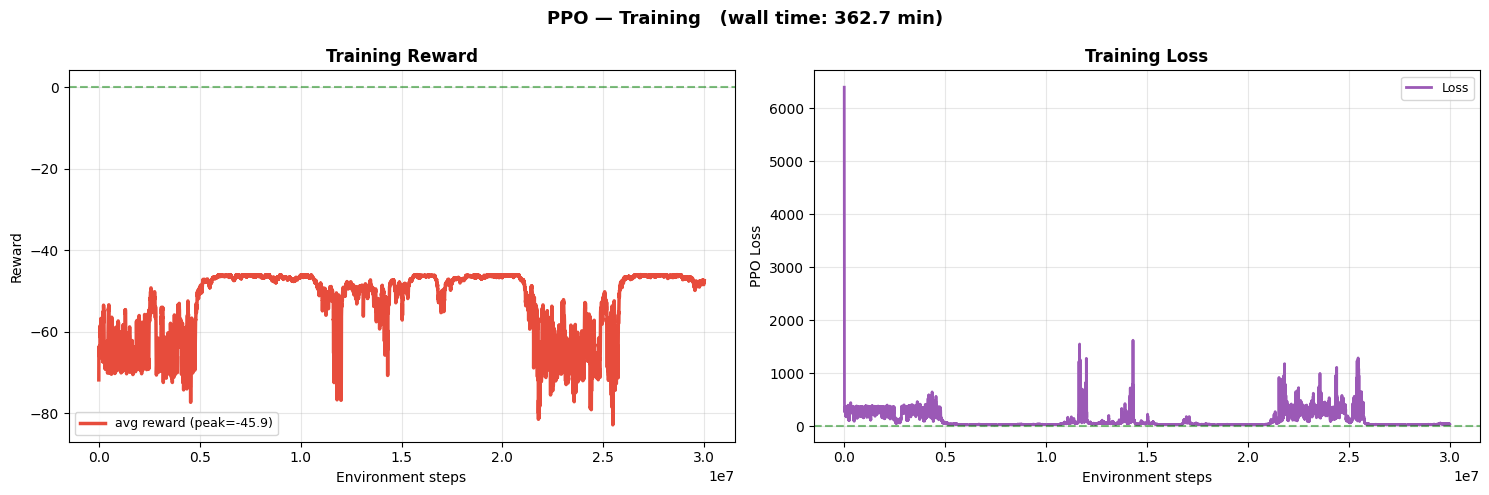

Saved: ppo_loss_reward.png
Training (wall) time: 362.7 min  (21763 s)


In [14]:
plot_loss_reward(logger=logger, algo="PPO")

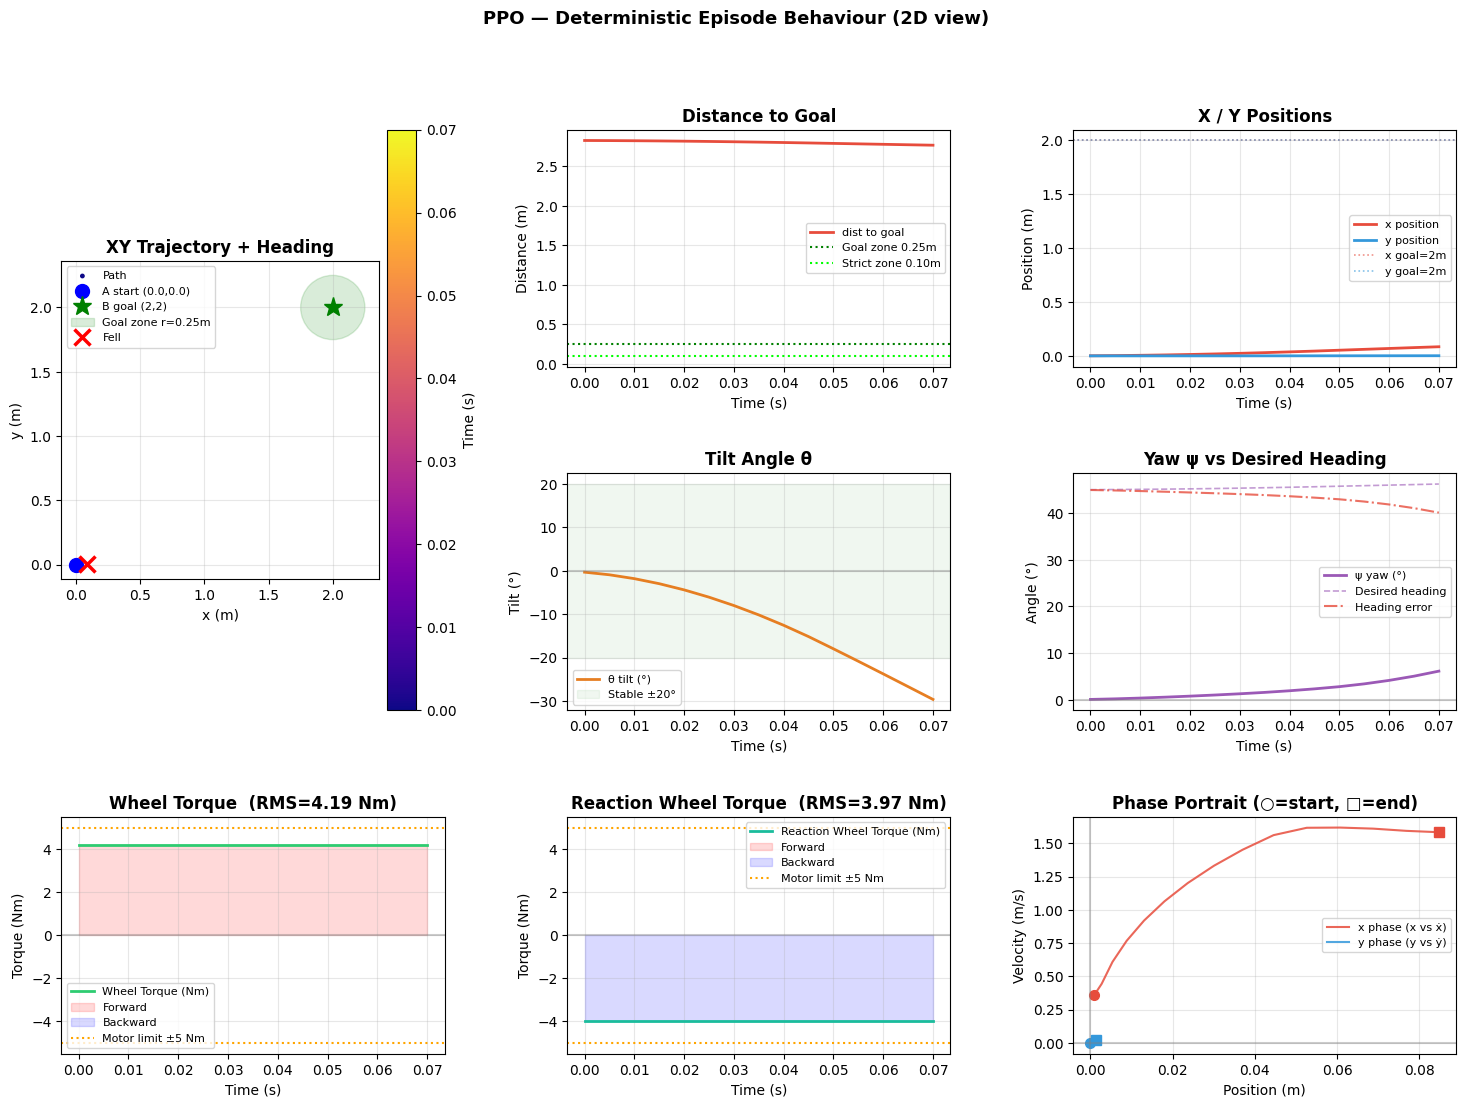

Saved: ppo_episode_traces_2d.png

  PPO Episode Summary
  Duration      : 0.1s  (15 steps)
  Final pos     : (0.085, 0.001)m
  Final dist    : 2.768m  (goal=2,2)
  Avg tilt      : 12.1°
  Max tilt      : 29.6°
  Wheel RMS     : 4.186 Nm  (sat 0%)
  React RMS     : 3.972 Nm  (sat 0%)
  Result        : FELL


{'final_x': 0.0847604051232338,
 'final_y': 0.001348089543171227,
 'final_dist': 2.768167734146118,
 'avg_tilt': 12.073869705200195,
 'w_torque_rms': 4.185950756072998,
 'r_torque_rms': 3.9718575477600098,
 'arrived': False,
 'fell': True,
 'duration_s': 0.07}

In [15]:
plot_episode_traces(net, algo="PPO", XML_PATH=XML_PATH, get_z_for_tilt=get_z_for_tilt,
                    mode="2d", x_goal=2, y_goal=2, get_obs=get_obs)

In [16]:
# def train_nav(x_start=0.0, x_goal=2.0, y_start=0.0, y_goal=2.0,
#               seed=42, tag="nav_v4",
#               max_episodes=8000):
#     torch.manual_seed(seed)
#     np.random.seed(seed)

#     net       = NavPPO(torque_max=5.0)
#     optimizer = optim.Adam(
#         net.parameters(), lr=3e-4, eps=1e-5)

#     STEPS        = 2048
#     EPOCHS       = 10
#     CLIP         = 0.2
#     GAMMA        = 0.99
#     LAM          = 0.95
#     MB           = 256
#     ENT_START    = 0.01
#     ENT_END   = 0.002
#     ENT_DECAY = 3000   # episodes
#     MAX_EP_STEPS = 3000
    
    

#     rewards      = []
#     losses       = []
#     best_avg     = -9999
#     best_weights = None

#     def gae(rews, vals, dones, nv):
#         adv, g = [], 0
#         for r, v, d in zip(
#                 reversed(rews),
#                 reversed(vals),
#                 reversed(dones)):
#             delta = r + GAMMA*nv*(1-d) - v
#             g     = delta + GAMMA*LAM*(1-d)*g
#             adv.insert(0, g); nv = v
#         return adv

#     model = mujoco.MjModel.from_xml_path(XML_PATH)
#     data  = mujoco.MjData(model)
#     dt    = model.opt.timestep

#     def reset_env():
#         mujoco.mj_resetData(model, data)
#         data.qpos[0]   = x_start # start at A
#         data.qpos[1]   = 0.0 # 
#         data.qpos[2]   = get_z_for_tilt(0.0) #
#         data.qpos[3:7] = [1, 0, 0, 0] # 
#         data.qvel[:]   = 0.0 # start stationary
#         data.qvel[4]   = np.random.uniform(
#             -0.01, 0.01) # small random initial tilt velocity
#         mujoco.mj_forward(model, data)
#         return get_obs(data)

#     def env_step(wheel_torque, reaction_torque):
#         u_wheel = float(np.clip(wheel_torque, -5., 5.))
#         u_react = float(np.clip(reaction_torque, -5., 5.))
#         data.ctrl[0] = -u_wheel    # ← sign from verify_signs
#         data.ctrl[1] = u_react
#         mujoco.mj_step(model, data)
#         obs            = get_obs(data)
#         x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs
#         dist_to_goal = np.sqrt((x - x_goal)**2 + (y - y_goal)**2)
#         goal_dist_to_origin = np.sqrt(x_goal**2 + y_goal**2)
#         done    = (dist_to_goal     > (1.5*goal_dist_to_origin) or abs(theta) > 0.5)
#         at_goal = (dist_to_goal < (0.1*goal_dist_to_origin) and abs(theta) < 0.25)   # ← must be upright at B
#         return obs, done, at_goal

#     obs          = reset_env()
#     ep_total     = 0.0
#     prev_pos     = np.array([obs[0], obs[2]])
#     ep_count     = 0
#     arrivals     = 0
#     from collections import deque
#     recent_arrivals = deque(maxlen=200)
#     rollout      = 0
#     ep_step      = 0

#     print(f"\nPure PPO Navigation | "
#           f"A={x_start}m → B={x_goal}m")
#     print(f"  No PID — PPO controls torque directly")
#     print(f"  torque ∈ [-5, +5] Nm\n")
    
#     print(f"{'Roll':>6} | {'Ep':>5} | "
#         f"{'Avg':>8} | {'Rec%':>6} | "
#         f"{'Loss':>8} | {'std':>5}")
#     print("-" * 50)

#     ENT = ENT_START
#     while ep_count < max_episodes:
#         ol,al,rl,vl,ll,dl = [],[],[],[],[],[]
#         ep_rewards = []

#         for _ in range(STEPS):
#             with torch.no_grad():
#                 wheel_torque, reaction_torque, logp, value = net.get_action(obs, x_goal, y_goal, deterministic=False)

#             ep_step += 1
#             obs2, done, at_goal = env_step(wheel_torque, reaction_torque)

#             r = nav_reward(
#                 obs2, prev_pos, x_goal, y_goal,
#                 at_goal, done, ep_step)

#             ep_total += r
#             prev_pos    = np.array([obs2[0], obs2[2]])

#             inp = np.array([
#                 *normalize_obs(obs),
#                 np.clip(
#                     (x_goal-obs[0])/5.,-1,1)],
#                 dtype=np.float32)

#             ol.append(inp)
#             al.append([torque])
#             rl.append(r)
#             vl.append(value.item())
#             ll.append(logp.item())
#             dl.append(float(done or at_goal))

#             obs = obs2

#             timeout = (ep_step >= MAX_EP_STEPS)
#             if done or at_goal or timeout:
#                 if at_goal:
#                     arrivals += 1
#                 recent_arrivals.append(1 if at_goal else 0)
#                 if timeout and not at_goal:
#                     rl[-1] -= 5.0
#                 ep_rewards.append(ep_total)
#                 ep_total  = 0.0
#                 ep_step   = 0
#                 ep_count += 1
#                 ENT = ENT_START + (ENT_END - ENT_START) * min(1.0, ep_count / ENT_DECAY)
#                 obs       = reset_env()
#                 prev_pos    = np.array([obs[0], obs[2]])

#         # PPO update #########################
#         with torch.no_grad():
#             inp = np.array([
#                 *normalize_obs(obs),
#                 np.clip(
#                     (x_goal-obs[0])/5.,-1,1)],
#                 dtype=np.float32)
#             _, nv = net(torch.FloatTensor(inp))

#         advantages = gae(rl, vl, dl, nv.item())
#         returns    = [a+v for a,v
#                       in zip(advantages, vl)]
#         n = len(ol)

#         obs_t  = torch.FloatTensor(np.array(ol))
#         act_t  = torch.FloatTensor(al)
#         ret_t  = torch.FloatTensor(returns)
#         adv_t  = torch.FloatTensor(advantages)
#         logp_t = torch.FloatTensor(ll)
#         adv_t  = ((adv_t - adv_t.mean()) /
#                   (adv_t.std() + 1e-8))

#         batch_loss = 0.0
#         for _ in range(EPOCHS):
#             idx = torch.randperm(n)
#             for s in range(0, n, MB):
#                 i = idx[s:s+MB]
#                 mean, vals = net(obs_t[i])
#                 std  = net.actor_log_std.exp().clamp(0.1, 2.0)
#                 dist = torch.distributions.Normal(mean, std)
#                 raw  = torch.atanh(
#                     (act_t[i] / net.torque_max).clamp(-0.999, 0.999))
#                 nlp  = dist.log_prob(raw).sum(-1)
#                 ent  = dist.entropy().mean()
#                 ratio = (nlp - logp_t[i]).exp().clamp(0., 10.)
#                 s1   = ratio * adv_t[i]
#                 s2_  = torch.clamp(ratio, 1-CLIP, 1+CLIP) * adv_t[i]
#                 loss = (
#                     -torch.min(s1, s2_).mean()
#                     + 0.5 * nn.MSELoss()(vals.squeeze(), ret_t[i])
#                     - ENT * ent)
#                 optimizer.zero_grad()
#                 loss.backward()
#                 nn.utils.clip_grad_norm_(net.parameters(), 0.5)
#                 optimizer.step()
#                 with torch.no_grad():
#                     net.actor_log_std.clamp_(-1.5, 0.7)
#                 batch_loss += loss.item()

            

#         rollout += 1
#         rewards.extend(ep_rewards)
#         losses.append(batch_loss)

#         if ep_rewards:
#             avg = float(np.mean(
#                 rewards[-min(100,len(rewards)):]))
#             arr_pct    = arrivals / max(ep_count, 1) * 100
#             recent_pct = np.mean(recent_arrivals) * 100 if recent_arrivals else 0.0
#             cur_std = float(
#                 net.actor_log_std.exp().item())

#             if avg > best_avg:
#                 best_avg     = avg
#                 best_weights = {
#                     k: v.clone() for k,v
#                     in net.state_dict().items()}
#                 torch.save(
#                     net.state_dict(),
#                     f"{SAVE_DIR}/nav_{tag}.pth")

#             if rollout % 5 == 0:
#                 icon = ("✅" if avg >  0 else
#                         "🔄" if avg > -20 else
#                         "⏳")
#                 print(f"{rollout:>6} | "
#                     f"{ep_count:>5} | "
#                     f"{avg:>8.2f} | "
#                     f"{recent_pct:>5.1f}% | "  # ← recent window (replaces or adds to arr_pct)
#                     f"{batch_loss:>8.3f} | "
#                     f"{cur_std:.3f} {icon}",
#                     flush=True)

#     if best_weights:
#         net.load_state_dict(best_weights)
#     return net, rewards, losses


# nav_net, nav_rewards, nav_losses = train_nav(
#     x_start=0.0, x_goal=2.0,
#     seed=42, tag="nav_v4_1",
#     max_episodes=5000)